In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [5]:
df = pd.read_csv("Sample - Superstore Sales (Excel) .csv")

In [6]:
print(df.head())

   Row ID  Order ID Order Date       Year Month Number Month Name  \
0     1.0       3.0 2010-10-13 1905-07-02   1900-01-10    October   
1     2.0       6.0 2012-02-20 1905-07-04   1900-01-02   February   
2     3.0      32.0 2011-07-15 1905-07-03   1900-01-07       July   
3     5.0      32.0 2011-07-15 1905-07-03   1900-01-07       July   
4     6.0      32.0 2011-07-15 1905-07-03   1900-01-07       July   

  Order Priority  Order Quantity      Sales  Discount  ... Zip Code  \
0            Low             6.0   261.5400      0.04  ...  60035.0   
1  Not Specified             2.0     6.9300      0.01  ...  98026.0   
2           High            26.0  2808.0800      0.07  ...  98387.0   
3           High            23.0   160.2335      0.04  ...  98387.0   
4           High            15.0   140.5600      0.04  ...  27260.0   

            State   Region  Customer Segment Product Category  \
0        Illinois  Central    Small Business  Office Supplies   
1      Washington     West  

In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048574 entries, 0 to 1048573
Data columns (total 26 columns):
 #   Column                Non-Null Count    Dtype         
---  ------                --------------    -----         
 0   Row ID                8398 non-null     float64       
 1   Order ID              8398 non-null     float64       
 2   Order Date            8398 non-null     datetime64[ns]
 3   Year                  1048574 non-null  datetime64[ns]
 4   Month Number          1048574 non-null  datetime64[ns]
 5   Month Name            1048574 non-null  object        
 6   Order Priority        8398 non-null     object        
 7   Order Quantity        8398 non-null     float64       
 8   Sales                 8398 non-null     float64       
 9   Discount              8398 non-null     float64       
 10  Ship Mode             8398 non-null     object        
 11  Profit                8398 non-null     float64       
 12  Unit Price            8398 non-null     fl

In [8]:
df = df.dropna()

In [9]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [10]:
df["Year"] = df["Order Date"].dt.year

In [11]:
print(df[["Order Date", "Year"]].head())

  Order Date  Year
0 2010-10-13  2010
1 2012-02-20  2012
2 2011-07-15  2011
3 2011-07-15  2011
4 2011-07-15  2011


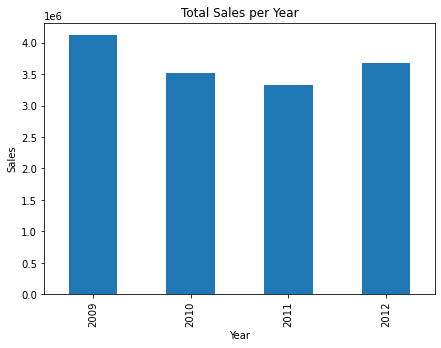

In [12]:
plt.figure(figsize=(7,5))
df.groupby("Year")["Sales"].sum().plot(kind="bar")
plt.title("Total Sales per Year")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.show()

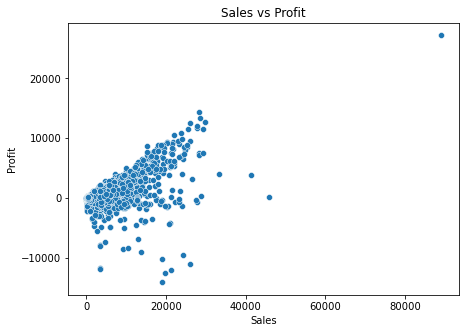

In [13]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="Sales", y="Profit")
plt.title("Sales vs Profit")
plt.show()

In [14]:
numeric_df = df.select_dtypes(include=["float64", "int64"])

In [15]:
X = numeric_df.drop("Sales", axis=1)
y = numeric_df["Sales"]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [18]:
y_pred = model.predict(X_test)

In [19]:
print("MAE:", mean_absolute_error(y_test, y_pred))

MAE: 709.7966290899574


In [20]:
print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.8064091647921225


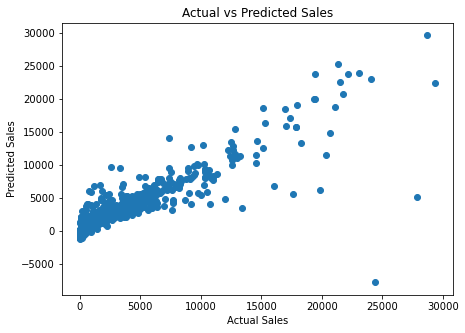

In [21]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

In [22]:
df.to_excel("clean_superstore.xlsx", index=False)

In [24]:
df.to_csv("clean_superstore.csv", index=False)

In [26]:
df.to_csv("clean_superstore.csv", index=False)